# 🔗 Bloque 3 — Sesión 2: Cramér's V, significación estadística y selección de variables

**Módulo:** Depuración, Limpieza y Clasificación de Datos (5109)  
**Unidad Didáctica:** UD2 — Verificación estadística de la calidad de los datos  
**Duración estimada:** ~4 horas

---

### Contenidos de esta sesión
- **3.4** Cramér's V: asociación entre variables categóricas
- **3.5** Significación estadística: p-valor, nivel de confianza e intervalo de confianza
- **3.6** Selección de variables: matrices de correlación, multicolinealidad y criterios de descarte

### Criterios de evaluación asociados
> **(CE a)** Se han descrito las técnicas estadísticas de análisis de la calidad técnica de los datos.  
> **(CE b)** Se han aplicado técnicas de evaluación basadas en cálculos estadísticos para detectar la cobertura y el sesgo.  
> **(CE c)** Se ha documentado la descripción del resultado de las verificaciones para que se tomen decisiones de diseño.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, chi2_contingency
from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
np.random.seed(42)

titanic = sns.load_dataset('titanic')
diamonds = sns.load_dataset('diamonds')
penguins = sns.load_dataset('penguins').dropna()

print('✅ Librerías y datasets cargados')

✅ Librerías y datasets cargados


---
## 3.4 Cramér's V: asociación entre variables categóricas

Pearson y Spearman miden relaciones entre variables numéricas. Para cuantificar la **asociación entre dos variables categóricas** necesitamos **Cramér's V**.

### Fundamento: el test chi-cuadrado (χ²)

Cramér's V se basa en el estadístico chi-cuadrado:

$$\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

Cramér's V normaliza el χ² para obtener un valor entre 0 y 1:

$$V = \sqrt{\frac{\chi^2 / n}{\min(k-1, r-1)}}$$

| Valor de V | Interpretación |
|-----------|---------------|
| 0.00 – 0.10 | Asociación muy débil o nula |
| 0.10 – 0.30 | Asociación débil |
| 0.30 – 0.50 | Asociación moderada |
| 0.50 – 1.00 | Asociación fuerte |

In [2]:
def cramers_v(col1, col2):
    """Calcula el coeficiente V de Cramér entre dos variables categóricas."""
    tabla = pd.crosstab(col1, col2)
    chi2, p, dof, _ = chi2_contingency(tabla)
    n = tabla.sum().sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    return v, p

pares = [
    ('sex', 'survived'),
    ('pclass', 'survived'),
    ('embarked', 'survived'),
    ('sex', 'pclass'),
    ('embarked', 'pclass'),
]

print(f"{'Par de variables':<35} {'Cramér V':>10} {'p-valor':>12} {'Asociación':>20}")
print('─' * 80)
for c1, c2 in pares:
    df_tmp = titanic[[c1, c2]].dropna()
    V, p = cramers_v(df_tmp[c1], df_tmp[c2])
    if V < 0.10: etiqueta = 'Muy débil'
    elif V < 0.30: etiqueta = 'Débil'
    elif V < 0.50: etiqueta = 'Moderada'
    else: etiqueta = '⚠️ Fuerte'
    print(f"{c1} vs {c2:<25} {V:>10.4f} {p:>12.6f} {etiqueta:>20}")

Par de variables                      Cramér V      p-valor           Asociación
────────────────────────────────────────────────────────────────────────────────
sex vs survived                      0.5409     0.000000            ⚠️ Fuerte
pclass vs survived                      0.3398     0.000000             Moderada
embarked vs survived                      0.1726     0.000002                Débil
sex vs pclass                        0.1380     0.000206                Débil
embarked vs pclass                        0.2638     0.000000                Débil


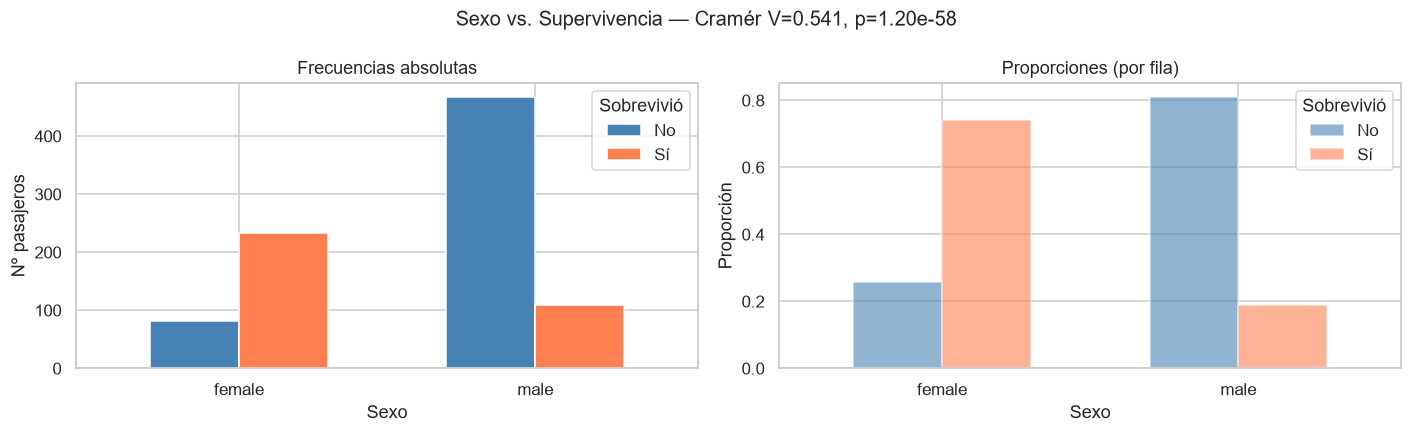

In [3]:
tabla_sv = pd.crosstab(titanic['sex'], titanic['survived'],
                        rownames=['Sexo'], colnames=['Sobrevivió'])
tabla_sv.columns = ['No', 'Sí']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

tabla_sv.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'],
              edgecolor='white', width=0.6)
axes[0].set_title('Frecuencias absolutas')
axes[0].set_xlabel('Sexo')
axes[0].set_ylabel('Nº pasajeros')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sobrevivió')

tabla_pct = tabla_sv.div(tabla_sv.sum(axis=1), axis=0)
tabla_pct.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'],
               edgecolor='white', width=0.6, alpha=0.6)
axes[1].set_title('Proporciones (por fila)')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Proporción')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sobrevivió')

V, p = cramers_v(titanic['sex'].dropna(), titanic['survived'].dropna())
plt.suptitle(f"Sexo vs. Supervivencia — Cramér V={V:.3f}, p={p:.2e}", fontsize=13)
plt.tight_layout()
plt.show()

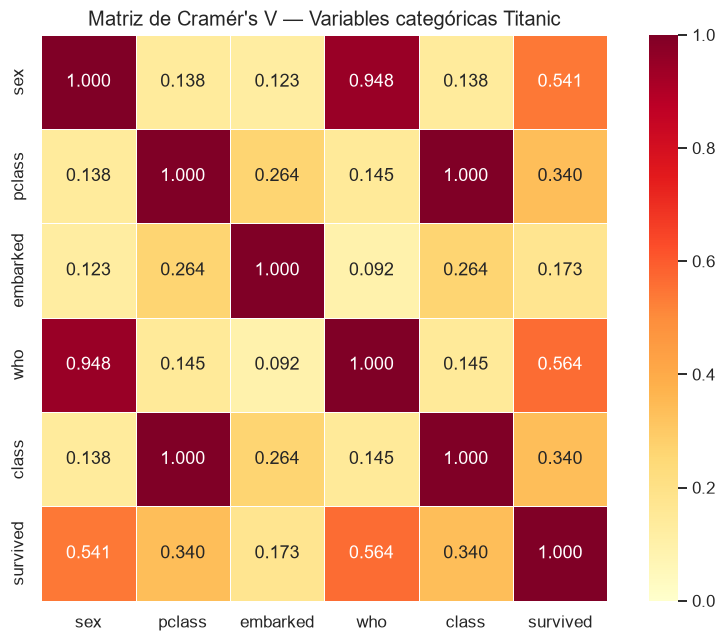

In [4]:
def matriz_cramers_v(df, columnas_cat):
    """Calcula la matriz de Cramér's V para un conjunto de variables categóricas."""
    n = len(columnas_cat)
    matrix = pd.DataFrame(np.zeros((n, n)), index=columnas_cat, columns=columnas_cat)
    for i, c1 in enumerate(columnas_cat):
        for j, c2 in enumerate(columnas_cat):
            if i == j:
                matrix.loc[c1, c2] = 1.0
            elif i < j:
                df_tmp = df[[c1, c2]].dropna()
                V, _ = cramers_v(df_tmp[c1], df_tmp[c2])
                matrix.loc[c1, c2] = V
                matrix.loc[c2, c1] = V
    return matrix

cols_cat = ['sex', 'pclass', 'embarked', 'who', 'class', 'survived']
mv = matriz_cramers_v(titanic, cols_cat)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(mv, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1, linewidths=0.5, linecolor='white',
            ax=ax, square=True)
ax.set_title("Matriz de Cramér's V — Variables categóricas Titanic", fontsize=13)
plt.tight_layout()
plt.show()

---
## 3.5 Significación estadística: p-valor, nivel de confianza e intervalo de confianza

### El p-valor

El **p-valor** responde a: *si en la población real no hubiera relación (H₀), ¿cuál sería la probabilidad de observar un resultado al menos tan extremo como el medido?*

- **p-valor < α** → rechazamos H₀ → resultado **estadísticamente significativo**
- **p-valor ≥ α** → no podemos rechazar H₀

El umbral habitual es **α = 0.05**.

> ⚠️ **Errores frecuentes:**  
> – El p-valor NO es la probabilidad de que H₀ sea verdadera.  
> – Significativo ≠ importante. Con n grande, correlaciones tiny pueden ser 'significativas'.  
> – No significativo ≠ sin efecto.

In [5]:
cols_num = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
print('Correlaciones de Pearson con p-valor (Penguins):\n')
print(f"{'Par':<45} {'r':>8} {'p-valor':>12} {'Significativa (α=0.05)?':>25}")
print('─' * 93)

for i, c1 in enumerate(cols_num):
    for j, c2 in enumerate(cols_num):
        if j <= i: continue
        r, p = pearsonr(penguins[c1], penguins[c2])
        sig = '✅ Sí' if p < 0.05 else '❌ No'
        print(f"{c1} vs {c2:<30} {r:>8.4f} {p:>12.6f} {sig:>25}")

Correlaciones de Pearson con p-valor (Penguins):

Par                                                  r      p-valor   Significativa (α=0.05)?
─────────────────────────────────────────────────────────────────────────────────────────────
bill_length_mm vs bill_depth_mm                   -0.2286     0.000025                      ✅ Sí
bill_length_mm vs flipper_length_mm                0.6531     0.000000                      ✅ Sí
bill_length_mm vs body_mass_g                      0.5895     0.000000                      ✅ Sí
bill_depth_mm vs flipper_length_mm               -0.5778     0.000000                      ✅ Sí
bill_depth_mm vs body_mass_g                     -0.4720     0.000000                      ✅ Sí
flipper_length_mm vs body_mass_g                      0.8730     0.000000                      ✅ Sí


In [6]:
r_real = 0.15
resultados = []
for n in [20, 50, 100, 200, 500, 1000, 5000]:
    x = np.random.normal(0, 1, n)
    y = r_real * x + np.sqrt(1 - r_real**2) * np.random.normal(0, 1, n)
    r_obs, p = pearsonr(x, y)
    resultados.append({'n': n, 'r observado': round(r_obs, 4),
                        'p-valor': round(p, 5), 'Significativa': p < 0.05})

df_res = pd.DataFrame(resultados).set_index('n')
print(f'Correlación real en la población: r = {r_real}')
print()
print(df_res.to_string())
print()
print('→ La misma correlación de r≈0.15 pasa de no significativa a muy significativa')
print('  simplemente aumentando el tamaño de la muestra.')

Correlación real en la población: r = 0.15

      r observado  p-valor  Significativa
n                                        
20        -0.0069  0.97690          False
50        -0.0361  0.80340          False
100        0.0151  0.88153          False
200        0.2443  0.00049           True
500        0.1419  0.00147           True
1000       0.1638  0.00000           True
5000       0.1470  0.00000           True

→ La misma correlación de r≈0.15 pasa de no significativa a muy significativa
  simplemente aumentando el tamaño de la muestra.


### Intervalo de confianza para la correlación

El **intervalo de confianza** (IC) indica el rango dentro del cual cae el verdadero parámetro poblacional con una probabilidad dada (95%).

Para la correlación de Pearson se usa la **transformación z de Fisher**:

$$z = \frac{1}{2} \ln\left(\frac{1+r}{1-r}\right), \quad SE_z = \frac{1}{\sqrt{n-3}}$$

In [7]:
def ic_pearson(r, n, alpha=0.05):
    """IC para la correlación de Pearson mediante la z de Fisher."""
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    z_crit = stats.norm.ppf(1 - alpha / 2)
    z_lo = z - z_crit * se
    z_hi = z + z_crit * se
    return np.tanh(z_lo), np.tanh(z_hi)

r_obs = 0.60
print(f'IC al 95% para r = {r_obs}:\n')
print(f"{'n':>6}  {'IC inferior':>12}  {'IC superior':>12}  {'Amplitud':>10}")
print('─' * 45)
for n in [20, 50, 100, 300, 1000]:
    lo, hi = ic_pearson(r_obs, n)
    print(f'{n:>6}  {lo:>12.4f}  {hi:>12.4f}  {hi-lo:>10.4f}')
print()
print('→ Con n=20, el IC es amplísimo. Con n=1000, el IC es preciso.')

IC al 95% para r = 0.6:

     n   IC inferior   IC superior    Amplitud
─────────────────────────────────────────────
    20        0.2144        0.8238      0.6094
    50        0.3861        0.7526      0.3665
   100        0.4575        0.7125      0.2550
   300        0.5222        0.6679      0.1456
  1000        0.5588        0.6383      0.0795

→ Con n=20, el IC es amplísimo. Con n=1000, el IC es preciso.


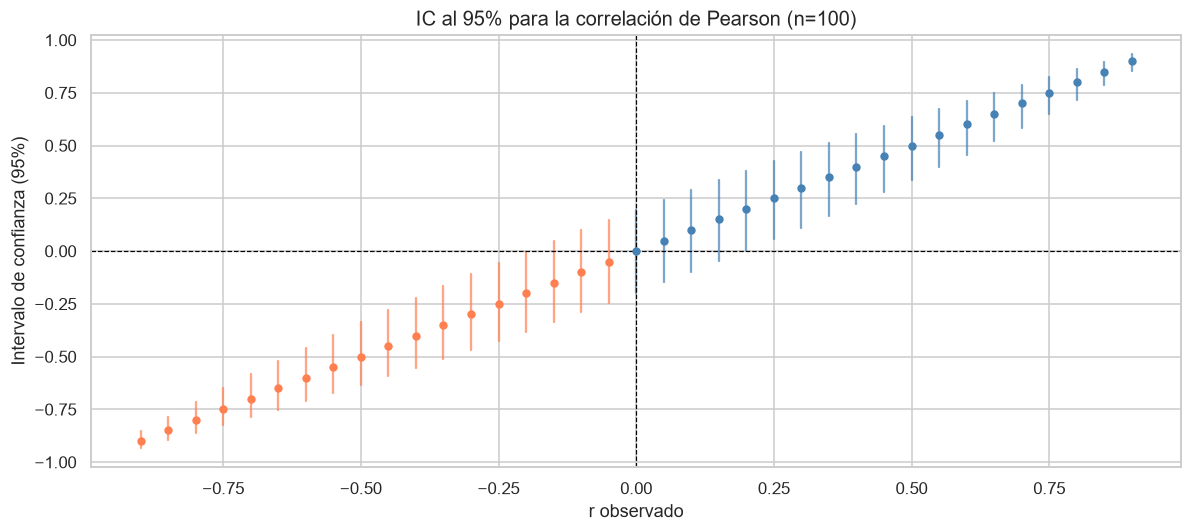

In [8]:
n = 100
r_vals = np.linspace(-0.9, 0.9, 37)
fig, ax = plt.subplots(figsize=(11, 5))

for r_v in r_vals:
    lo, hi = ic_pearson(r_v, n)
    color = 'steelblue' if r_v >= 0 else 'coral'
    ax.plot([r_v, r_v], [lo, hi], color=color, linewidth=1.5, alpha=0.7)
    ax.scatter([r_v], [r_v], color=color, s=20, zorder=3)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('r observado')
ax.set_ylabel('Intervalo de confianza (95%)')
ax.set_title(f'IC al 95% para la correlación de Pearson (n={n})', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3.6 Selección de variables mediante correlación

### Multicolinealidad

Cuando dos o más variables predictoras están altamente correlacionadas entre sí, tenemos **multicolinealidad**. Causa problemas en regresión lineal/logística e interpretabilidad.

**Criterio habitual:** si |r| > 0.85 entre dos predictores, considerar eliminar uno.

In [9]:
cols_pred = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
r_mat = penguins[cols_pred].corr()

print('Pares con correlación alta (|r| > 0.7):')
print()
for i, c1 in enumerate(cols_pred):
    for j, c2 in enumerate(cols_pred):
        if j <= i: continue
        r = r_mat.loc[c1, c2]
        if abs(r) > 0.7:
            nivel = '⚠️ Multicolinealidad severa' if abs(r) > 0.85 else '〰️ Correlación alta'
            print(f'  {c1} vs {c2}: r = {r:.3f}  {nivel}')

Pares con correlación alta (|r| > 0.7):

  flipper_length_mm vs body_mass_g: r = 0.873  ⚠️ Multicolinealidad severa


In [10]:
def informe_seleccion_variables(df, cols_predictoras, col_objetivo=None,
                                 umbral_multicolinealidad=0.85,
                                 umbral_relevancia=0.10):
    """Informe de selección de variables por correlación."""
    datos = df[cols_predictoras + ([col_objetivo] if col_objetivo else [])].dropna()

    print('=' * 65)
    print('INFORME DE SELECCIÓN DE VARIABLES')
    print('=' * 65)

    if col_objetivo:
        print(f"\n1. CORRELACIÓN CON '{col_objetivo}':")
        print(f'   (umbral mínimo: |r| > {umbral_relevancia})')
        print()
        relevancia = []
        for col in cols_predictoras:
            try:
                r, p = pearsonr(datos[col], datos[col_objetivo])
            except Exception:
                r, p = 0, 1
            relevante = '✅' if abs(r) > umbral_relevancia and p < 0.05 else '❌ Baja'
            relevancia.append((col, r, p, relevante))
            print(f'   {col:<25} r={r:+.3f}  p={p:.4f}  {relevante}')

    print(f'\n2. MULTICOLINEALIDAD (umbral: |r| > {umbral_multicolinealidad}):')
    r_pred = datos[cols_predictoras].corr()
    hay_multi = False
    for i, c1 in enumerate(cols_predictoras):
        for j, c2 in enumerate(cols_predictoras):
            if j <= i: continue
            r = r_pred.loc[c1, c2]
            if abs(r) > umbral_multicolinealidad:
                print(f'   ⚠️  {c1} vs {c2}: r = {r:.3f}')
                hay_multi = True
    if not hay_multi:
        print('   ✅ No se detecta multicolinealidad severa.')

    print('\n' + '=' * 65)

cols_pred_p = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']
informe_seleccion_variables(penguins, cols_pred_p, col_objetivo='body_mass_g')

INFORME DE SELECCIÓN DE VARIABLES

1. CORRELACIÓN CON 'body_mass_g':
   (umbral mínimo: |r| > 0.1)

   bill_length_mm            r=+0.589  p=0.0000  ✅
   bill_depth_mm             r=-0.472  p=0.0000  ✅
   flipper_length_mm         r=+0.873  p=0.0000  ✅

2. MULTICOLINEALIDAD (umbral: |r| > 0.85):
   ✅ No se detecta multicolinealidad severa.



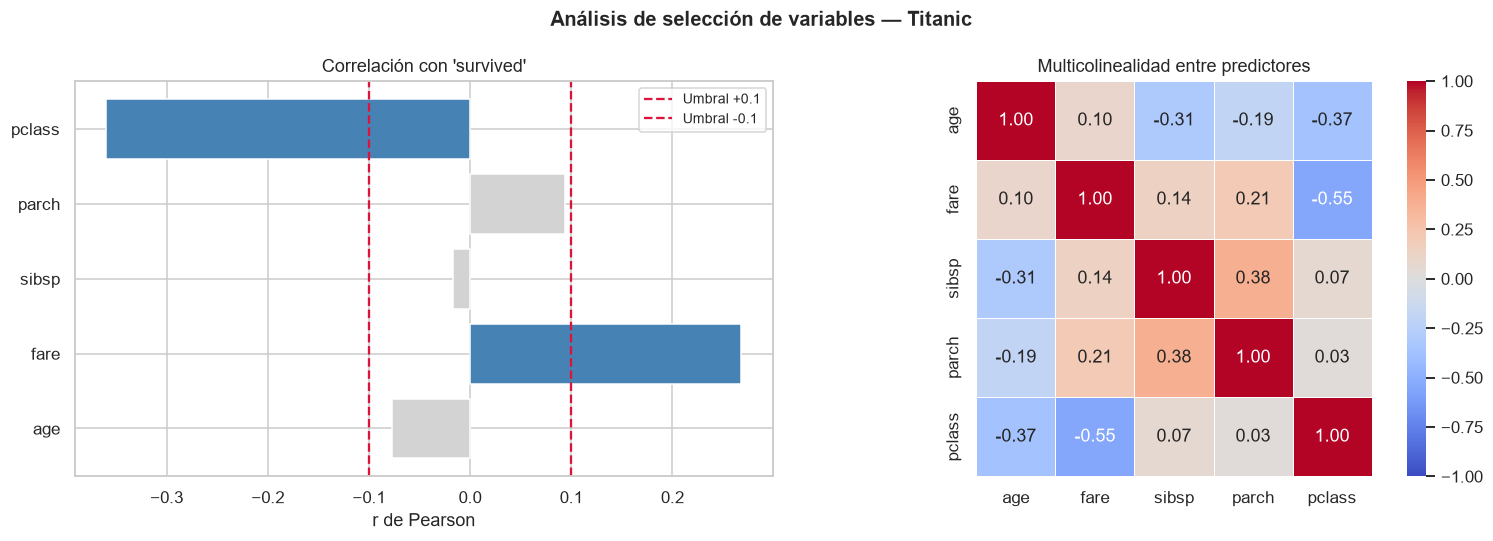

In [11]:
cols_titanic = ['age', 'fare', 'sibsp', 'parch', 'pclass']
objetivo = 'survived'
df_t = titanic[cols_titanic + [objetivo]].dropna()
df_t = df_t.copy()
df_t['pclass'] = df_t['pclass'].astype(float)

r_obj = df_t[cols_titanic].corrwith(df_t[objetivo])
r_pred = df_t[cols_titanic].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = ['steelblue' if abs(v) > 0.1 else 'lightgray' for v in r_obj]
axes[0].barh(r_obj.index, r_obj.values, color=colores, edgecolor='white')
axes[0].axvline(0.1, color='crimson', linestyle='--', linewidth=1.5, label='Umbral +0.1')
axes[0].axvline(-0.1, color='crimson', linestyle='--', linewidth=1.5, label='Umbral -0.1')
axes[0].set_title(f"Correlación con '{objetivo}'", fontsize=12)
axes[0].set_xlabel('r de Pearson')
axes[0].legend(fontsize=9)

sns.heatmap(r_pred, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            ax=axes[1], square=True)
axes[1].set_title('Multicolinealidad entre predictores', fontsize=12)

plt.suptitle('Análisis de selección de variables — Titanic', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
informe_seleccion_variables(
    df_t, cols_titanic, col_objetivo='survived',
    umbral_multicolinealidad=0.85, umbral_relevancia=0.10
)

INFORME DE SELECCIÓN DE VARIABLES

1. CORRELACIÓN CON 'survived':
   (umbral mínimo: |r| > 0.1)

   age                       r=-0.077  p=0.0391  ❌ Baja
   fare                      r=+0.268  p=0.0000  ✅
   sibsp                     r=-0.017  p=0.6433  ❌ Baja
   parch                     r=+0.093  p=0.0126  ❌ Baja
   pclass                    r=-0.360  p=0.0000  ✅

2. MULTICOLINEALIDAD (umbral: |r| > 0.85):
   ✅ No se detecta multicolinealidad severa.



---
## 🔧 Ejercicios

### Ejercicio 1 — Cramér's V en Diamonds

Calcula la matriz de Cramér's V entre `cut`, `color` y `clarity`. ¿Cuáles están más asociadas?

In [13]:
# cols_cat_d = ['cut', 'color', 'clarity']
# mv_d = matriz_cramers_v(diamonds, cols_cat_d)
# print(mv_d.round(3))

# fig, ax = plt.subplots(figsize=(6, 5))
# sns.heatmap(mv_d, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, vmax=1, ax=ax)
# plt.tight_layout()
# plt.show()

### Ejercicio 2 — IC de correlación

Para `flipper_length_mm` vs `body_mass_g` del dataset `penguins`:
1. Calcula r y su IC al 95%
2. Repite el cálculo con solo las primeras 20 filas. ¿Cómo cambia el IC?

In [14]:
# peng_full = penguins[['flipper_length_mm', 'body_mass_g']].dropna()
# r_full, _ = pearsonr(peng_full['flipper_length_mm'], peng_full['body_mass_g'])
# lo_full, hi_full = ic_pearson(r_full, len(peng_full))
# print(f'n={len(peng_full)}: r={r_full:.4f}  IC=[{lo_full:.4f}, {hi_full:.4f}]')

# peng_20 = peng_full.head(20)
# r_20, _ = pearsonr(peng_20['flipper_length_mm'], peng_20['body_mass_g'])
# lo_20, hi_20 = ic_pearson(r_20, 20)
# print(f'n=20: r={r_20:.4f}  IC=[{lo_20:.4f}, {hi_20:.4f}]')

### Ejercicio 3 — Informe de selección completo

Aplica `informe_seleccion_variables()` al dataset `diamonds` con variables numéricas `carat`, `depth`, `table`, `x`, `y`, `z` y objetivo `price`. ¿Qué variables descartarías? ¿Hay multicolinealidad entre `x`, `y` y `z`?

In [15]:
# informe_seleccion_variables(
#     diamonds, ['carat', 'depth', 'table', 'x', 'y', 'z'],
#     col_objetivo='price',
#     umbral_multicolinealidad=0.85, umbral_relevancia=0.2
# )

# ¿Qué subset de variables usarías para predecir el precio? Justifica.

---
## 📝 Resumen de la sesión

| Concepto | Clave |
|----------|-------|
| **Cramér's V** | Asociación entre categóricas. Rango [0,1]. Basado en chi-cuadrado. |
| **p-valor** | Probabilidad de observar el resultado si H₀ fuera cierta. Umbral: α=0.05. |
| **Significativo ≠ importante** | Con n grande, efectos mínimos pueden ser significativos. |
| **IC de Pearson** | Rango plausible para el r real. Se amplía con n pequeño. |
| **Multicolinealidad** | |r| > 0.85 entre predictores → redundancia → eliminar uno. |
| **Selección por correlación** | Combinar relevancia con objetivo + multicolinealidad. |

### 🔜 Próxima sesión
**Bloque 4 — Sesión 1:** Tests de independencia. Chi-cuadrado, t-test y Mann-Whitney.